# Synth Control Inference

Abadie-style placebo p-values and valid confidence intervals for synthetic control,
verified by Monte Carlo on a synthetic factor-model panel.

**Kernel:** select **`Python (synthcontrol)`** from the Jupyter kernel menu before running.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from joblib import Parallel, delayed

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

## 2. Synthetic DGP

In [2]:
def simulate_panel(J=30, T=40, T0=30, r=2, sigma=0.5, tau=0.0,
                   inside_hull=True, seed=0):
    """Generate a factor-model panel.

    y_{it} = mu_i + lambda_i^T F_t + eps_{it},  eps ~ N(0, sigma^2)
    Treated unit (id=0) has lambda_0 inside convex hull of donor lambdas
    when inside_hull=True. Treatment effect tau added to y_{0t} for t >= T0.
    """
    rng_local = np.random.default_rng(seed)
    n_units = J + 1  # unit 0 = treated, 1..J = donors

    donor_lambda = rng_local.standard_normal((J, r))
    if inside_hull:
        w = rng_local.dirichlet(np.ones(J))
        treated_lambda = w @ donor_lambda
    else:
        direction = rng_local.standard_normal(r)
        direction /= np.linalg.norm(direction)
        treated_lambda = donor_lambda.mean(axis=0) + 3.0 * direction

    lam = np.vstack([treated_lambda[None, :], donor_lambda])  # (n_units, r)
    mu = rng_local.standard_normal(n_units)
    F = rng_local.standard_normal((T, r))
    eps = rng_local.standard_normal((n_units, T)) * sigma

    y = mu[:, None] + lam @ F.T + eps
    y[0, T0:] += tau

    units = np.repeat(np.arange(n_units), T)
    times = np.tile(np.arange(T), n_units)
    df = pd.DataFrame({"unit": units, "time": times, "y": y.reshape(-1)})

    truth = {"tau": tau, "mu": mu, "lambda": lam, "F": F,
             "treated_id": 0, "T0": T0}
    return df, truth

### Validation: simulate_panel

In [3]:
def _validate_simulate_panel():
    df, truth = simulate_panel(J=30, T=40, T0=30, r=2, sigma=0.5, tau=1.0, seed=42)
    # Long format with the right columns
    assert list(df.columns) == ["unit", "time", "y"], df.columns.tolist()
    # 31 units (1 treated + 30 donors) x 40 time periods
    assert df["unit"].nunique() == 31
    assert df["time"].nunique() == 40
    assert len(df) == 31 * 40
    # Treated id is 0; donors are 1..30
    assert truth["treated_id"] == 0
    assert set(df["unit"].unique()) == set(range(31))
    # Treatment effect added only to treated unit's post-period
    treated_post = df.query("unit == 0 and time >= 30")["y"].to_numpy()
    treated_pre = df.query("unit == 0 and time < 30")["y"].to_numpy()
    # Re-simulate with tau=0 and same seed to get the counterfactual
    df0, _ = simulate_panel(J=30, T=40, T0=30, r=2, sigma=0.5, tau=0.0, seed=42)
    cf_post = df0.query("unit == 0 and time >= 30")["y"].to_numpy()
    cf_pre = df0.query("unit == 0 and time < 30")["y"].to_numpy()
    np.testing.assert_allclose(treated_pre, cf_pre)  # pre-period unchanged by tau
    np.testing.assert_allclose(treated_post - cf_post, 1.0)  # post shifted by tau
    # Determinism
    df_a, _ = simulate_panel(seed=7)
    df_b, _ = simulate_panel(seed=7)
    pd.testing.assert_frame_equal(df_a, df_b)
    # Inside-hull: treated lambda is convex combo of donor lambdas
    lam = truth["lambda"]  # shape (31, r)
    W = cp.Variable(30, nonneg=True)
    cp.Problem(cp.Minimize(cp.sum_squares(lam[1:].T @ W - lam[0])),
               [cp.sum(W) == 1]).solve()
    assert W.value is not None
    np.testing.assert_allclose(lam[1:].T @ W.value, lam[0], atol=1e-6)
    print("simulate_panel OK")

_validate_simulate_panel()

simulate_panel OK


## 3. SC estimator

In [4]:
def fit_sc(df, treated_id, T0):
    """Abadie SC matching on lagged outcomes only.
    Solve simplex-constrained QP for donor weights W via cvxpy/OSQP.
    Returns dict with gap (pd.Series, length T), yhat (pd.Series), W (pd.Series).
    """
    wide = df.pivot(index="time", columns="unit", values="y").sort_index()
    times = wide.index.to_numpy()
    donor_ids = [u for u in wide.columns if u != treated_id]
    y_treated = wide[treated_id].to_numpy()
    Y_donors = wide[donor_ids].to_numpy()
    J = Y_donors.shape[1]

    pre_mask = times < T0
    y1_pre = y_treated[pre_mask]
    Y0_pre = Y_donors[pre_mask, :]

    W_var = cp.Variable(J, nonneg=True)
    objective = cp.Minimize(cp.sum_squares(y1_pre - Y0_pre @ W_var))
    cp.Problem(objective, [cp.sum(W_var) == 1]).solve(solver=cp.OSQP)
    W_val = np.clip(W_var.value, 0.0, None)
    W_val = W_val / W_val.sum()

    yhat_full = Y_donors @ W_val
    gap_full = y_treated - yhat_full

    return {
        "gap":  pd.Series(gap_full,  index=times, name="gap"),
        "yhat": pd.Series(yhat_full, index=times, name="yhat"),
        "W":    pd.Series(W_val,     index=donor_ids, name="W"),
    }

### Validation: fit_sc

In [5]:
def _validate_fit_sc():
    df, _ = simulate_panel(J=30, T=40, T0=30, sigma=0.0, tau=0.0, seed=11)
    out = fit_sc(df, treated_id=0, T0=30)
    assert set(out.keys()) == {"gap", "W", "yhat"}
    assert isinstance(out["gap"], pd.Series)
    assert isinstance(out["W"], pd.Series)
    assert isinstance(out["yhat"], pd.Series)
    assert len(out["gap"]) == 40
    assert len(out["yhat"]) == 40
    assert len(out["W"]) == 30
    assert (out["W"] >= -1e-8).all()
    np.testing.assert_allclose(out["W"].sum(), 1.0, atol=1e-6)
    assert list(out["W"].index) == list(range(1, 31))
    pre_gap = out["gap"].iloc[:30]
    assert np.abs(pre_gap).max() < 1e-4, f"pre-period gap too large: {np.abs(pre_gap).max()}"
    post_gap = out["gap"].iloc[30:]
    assert np.abs(post_gap).max() < 1e-3, f"post-period gap too large: {np.abs(post_gap).max()}"

    df2, _ = simulate_panel(J=30, T=40, T0=30, sigma=0.3, tau=2.0, seed=11)
    out2 = fit_sc(df2, treated_id=0, T0=30)
    assert 1.0 < out2["gap"].iloc[30:].mean() < 3.0
    print("fit_sc OK")

_validate_fit_sc()

fit_sc OK


## 4. Phase I — Abadie p-values

In [6]:
def rmspe_ratio(gap, T0):
    """Post/pre RMSPE ratio. Pre-RMSPE in the denominator penalizes badly-fit donors."""
    pre = gap.iloc[:T0].to_numpy()
    post = gap.iloc[T0:].to_numpy()
    pre_rmspe = float(np.sqrt(np.mean(pre ** 2)))
    post_rmspe = float(np.sqrt(np.mean(post ** 2)))
    if pre_rmspe == 0.0:
        return np.inf
    return post_rmspe / pre_rmspe


def placebo_distribution(df, T0):
    """Refit SC with each unit as 'treated' in turn. Returns wide DataFrame
    (index=time, columns=unit) of gap series."""
    units = sorted(df["unit"].unique())
    gaps = {j: fit_sc(df, treated_id=j, T0=T0)["gap"] for j in units}
    return pd.DataFrame(gaps).sort_index()


def abadie_pvalue(ratios, treated_idx):
    """One-sided exact rank p-value: p = #{j : r_j >= r_treated} / (J+1).
    Numerator includes the treated unit, so p >= 1/(J+1) always. Ties counted (conservative).
    """
    r_t = ratios.loc[treated_idx]
    return float((ratios >= r_t).sum()) / len(ratios)

### Validation: placebo + rmspe_ratio + abadie_pvalue

In [7]:
def _validate_phase1():
    # rmspe_ratio: known input
    gap = pd.Series(np.array([0.1, -0.1, 0.1, -0.1, 2.0, 2.0]), index=np.arange(6))
    r = rmspe_ratio(gap, T0=4)
    expected = np.sqrt((4.0 + 4.0) / 2) / np.sqrt((0.01 * 4) / 4)  # = 2.0 / 0.1 = 20.0
    np.testing.assert_allclose(r, expected, rtol=1e-10)

    # abadie_pvalue: floor at 1/(J+1)
    ratios = pd.Series([5.0, 1.0, 1.0, 1.0], index=[0, 1, 2, 3])
    p = abadie_pvalue(ratios, treated_idx=0)
    assert p == 1 / 4, f"expected 0.25, got {p}"
    # Tie at the top: treated tied with one placebo -> count includes both
    ratios_tie = pd.Series([2.0, 2.0, 1.0, 1.0], index=[0, 1, 2, 3])
    p_tie = abadie_pvalue(ratios_tie, treated_idx=0)
    assert p_tie == 2 / 4, f"expected 0.5, got {p_tie}"

    # placebo_distribution: shape and column set
    df, _ = simulate_panel(J=10, T=20, T0=15, sigma=0.3, tau=1.0, seed=3)
    gaps = placebo_distribution(df, T0=15)
    assert gaps.shape == (20, 11)
    assert set(gaps.columns) == set(range(11))

    # End-to-end on a panel with strong tau
    df2, _ = simulate_panel(J=30, T=40, T0=30, sigma=0.3, tau=2.0, seed=5)
    gaps2 = placebo_distribution(df2, T0=30)
    ratios2 = gaps2.apply(lambda g: rmspe_ratio(g, T0=30))
    p2 = abadie_pvalue(ratios2, treated_idx=0)
    assert p2 <= 3 / 31, f"strong-effect p-value too large: {p2}"
    print("Phase I OK")

_validate_phase1()

Phase I OK


### Worked example: one panel at tau=1

Simulate one panel with a true treatment effect of tau=1, fit synthetic
control to every unit (treated + 30 placebos), compute the post/pre RMSPE
ratio for each, and report the Abadie rank p-value.

In [8]:
WORKED_PANEL_SEED = 42
df_worked, truth_worked = simulate_panel(
    J=30, T=40, T0=30, r=2, sigma=0.5, tau=1.0, seed=WORKED_PANEL_SEED,
)

gaps_worked = placebo_distribution(df_worked, T0=30)
ratios_worked = gaps_worked.apply(lambda g: rmspe_ratio(g, T0=30))
treated_id_worked = truth_worked["treated_id"]
tau_hat = float(gaps_worked[treated_id_worked].iloc[30:].mean())
r_treated = float(ratios_worked.loc[treated_id_worked])
p_worked = abadie_pvalue(ratios_worked, treated_idx=treated_id_worked)

print(f"Estimated tau (mean post-period gap): {tau_hat:+.3f}")
print(f"Treated unit RMSPE ratio:              {r_treated:.3f}")
print(f"Abadie one-sided p-value:              {p_worked:.4f}  (floor = {1/31:.4f})")

Estimated tau (mean post-period gap): +0.653
Treated unit RMSPE ratio:              1.815
Abadie one-sided p-value:              0.0645  (floor = 0.0323)


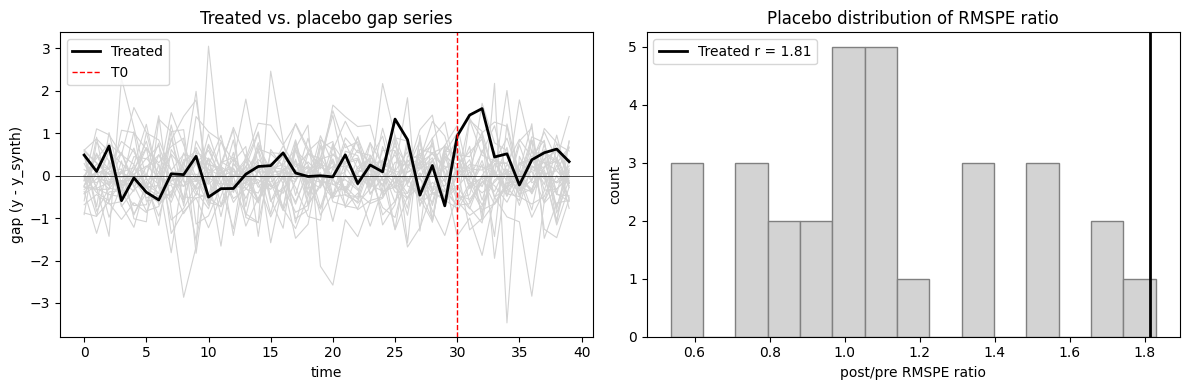

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for col in gaps_worked.columns:
    if col == treated_id_worked:
        continue
    ax.plot(gaps_worked.index, gaps_worked[col], color="lightgrey", lw=0.8)
ax.plot(gaps_worked.index, gaps_worked[treated_id_worked],
        color="black", lw=2, label="Treated")
ax.axvline(30, color="red", ls="--", lw=1, label="T0")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("time")
ax.set_ylabel("gap (y - y_synth)")
ax.set_title("Treated vs. placebo gap series")
ax.legend(loc="upper left")

ax = axes[1]
placebo_ratios = ratios_worked.drop(treated_id_worked)
ax.hist(placebo_ratios, bins=15, color="lightgrey", edgecolor="grey")
ax.axvline(r_treated, color="black", lw=2, label=f"Treated r = {r_treated:.2f}")
ax.set_xlabel("post/pre RMSPE ratio")
ax.set_ylabel("count")
ax.set_title("Placebo distribution of RMSPE ratio")
ax.legend()

fig.tight_layout()
plt.show()

## 5. Phase II — Confidence intervals

## 6. Phase III — Coverage simulation

## 7. Discussion